**Task 1: Data Preparation**
1. Load the dataset using sklearn.
2. Convert into DataFrame and explore structure.
3. Check missing values and duplicates.
4. Apply feature scaling using StandardScaler and justify its importance.





In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler


cancer=pd.read_csv("/brca.csv")


# Display first 5 rows
print(cancer.head())

cancer = cancer.drop("Unnamed: 0", axis=1)

print(cancer.head())

print("Shape of dataset:", cancer.shape)
print(cancer.columns)
cancer.info()
cancer.describe()

print(cancer.isnull().sum())

print("Duplicate rows:", cancer.duplicated().sum())

X = cancer.drop("y", axis=1)
y = cancer["y"]


y = y.map({"B":1, "M":0})
print(y.head())


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

X_scaled.describe()



   Unnamed: 0  x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
0           1         13.540           14.36             87.46        566.3   
1           2         13.080           15.71             85.63        520.0   
2           3          9.504           12.44             60.34        273.9   
3           4         13.030           18.42             82.61        523.8   
4           5          8.196           16.84             51.71        201.9   

   x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
0            0.09779             0.08129           0.06664   
1            0.10750             0.12700           0.04568   
2            0.10240             0.06492           0.02956   
3            0.08983             0.03766           0.02562   
4            0.08600             0.05943           0.01588   

   x.concave_pts_mean  x.symmetry_mean  ...  x.texture_worst  \
0            0.047810           0.1885  ...            19.26   
1            0.031100   

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
count,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,569.000000,5.690000e+02,5.690000e+02,5.690000e+02,...,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,569.000000,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02
mean,-1.998011e-16,-7.492542e-16,-9.990056e-17,-1.998011e-16,1.498508e-16,1.998011e-16,0.000000,9.990056e-17,1.498508e-16,4.745277e-16,...,-9.990056e-17,2.497514e-17,9.990056e-17,-1.998011e-16,-1.398608e-15,0.000000,9.990056e-17,2.997017e-16,2.497514e-16,1.998011e-16
std,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880,1.000880e+00,1.000880e+00,1.000880e+00,...,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00
min,-2.029648e+00,-2.229249e+00,-1.984504e+00,-1.454443e+00,-3.112085e+00,-1.610136e+00,-1.114873,-1.261820e+00,-2.744117e+00,-1.819865e+00,...,-1.726901e+00,-2.223994e+00,-1.693361e+00,-1.222423e+00,-2.682695e+00,-1.443878,-1.305831e+00,-1.745063e+00,-2.160960e+00,-1.601839e+00
25%,-6.893853e-01,-7.259631e-01,-6.919555e-01,-6.671955e-01,-7.109628e-01,-7.470860e-01,-0.743748,-7.379438e-01,-7.032397e-01,-7.226392e-01,...,-6.749213e-01,-7.486293e-01,-6.895783e-01,-6.421359e-01,-6.912304e-01,-0.681083,-7.565142e-01,-7.563999e-01,-6.418637e-01,-6.919118e-01
50%,-2.150816e-01,-1.046362e-01,-2.359800e-01,-2.951869e-01,-3.489108e-02,-2.219405e-01,-0.342240,-3.977212e-01,-7.162650e-02,-1.782793e-01,...,-2.690395e-01,-4.351564e-02,-2.859802e-01,-3.411812e-01,-4.684277e-02,-0.269501,-2.182321e-01,-2.234689e-01,-1.274095e-01,-2.164441e-01
75%,4.693926e-01,5.841756e-01,4.996769e-01,3.635073e-01,6.361990e-01,4.938569e-01,0.526062,6.469351e-01,5.307792e-01,4.709834e-01,...,5.220158e-01,6.583411e-01,5.402790e-01,3.575891e-01,5.975448e-01,0.539669,5.311411e-01,7.125100e-01,4.501382e-01,4.507624e-01
max,3.971288e+00,4.651889e+00,3.976130e+00,5.250529e+00,4.770911e+00,4.568425e+00,4.243589,3.927930e+00,4.484751e+00,4.910919e+00,...,4.094189e+00,3.885905e+00,4.287337e+00,5.930172e+00,3.955374e+00,5.112877,4.700669e+00,2.685877e+00,6.046041e+00,6.846856e+00


Why StandardScaler?

KNN is a distance-based algorithm. Features having larger values can dominate the distance calculation. StandardScaler converts every feature to the same scale (mean = 0 and standard deviation = 1), ensuring each feature contributes equally.

**Task 2: Train-Test Split Analysis**
1. Split dataset into training and testing sets (80:20).
2. Repeat with 70:30 and 90:10 splits.
3. Compare performance variations across splits.
4. Analyze how dataset splitting affects model stability and generalization.


Accuracy (80:20): 0.9298245614035088
Accuracy (70:30): 0.9590643274853801
Accuracy (90:10): 0.9298245614035088
  Train-Test Split  Accuracy
0            80:20  0.929825
1            70:30  0.959064
2            90:10  0.929825


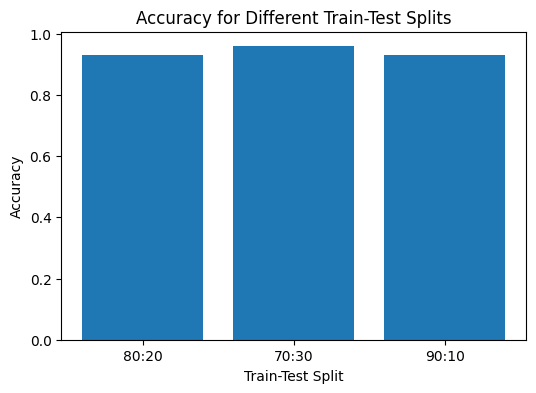

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 80:20 Split
X_train80, X_test80, y_train80, y_test80 = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

knn80 = KNeighborsClassifier(n_neighbors=5)
knn80.fit(X_train80, y_train80)

y_pred80 = knn80.predict(X_test80)

accuracy80 = accuracy_score(y_test80, y_pred80)

print("Accuracy (80:20):", accuracy80)



# 70:30 Split
X_train70, X_test70, y_train70, y_test70 = train_test_split(X_scaled, y, test_size=0.30, random_state=42)

knn70 = KNeighborsClassifier(n_neighbors=5)
knn70.fit(X_train70, y_train70)

y_pred70 = knn70.predict(X_test70)

accuracy70 = accuracy_score(y_test70, y_pred70)

print("Accuracy (70:30):", accuracy70)


# 90:10 Split
X_train90, X_test90, y_train90, y_test90 = train_test_split(X_scaled, y, test_size=0.10, random_state=42)

knn90 = KNeighborsClassifier(n_neighbors=5)
knn90.fit(X_train90, y_train90)

y_pred90 = knn90.predict(X_test90)

accuracy90 = accuracy_score(y_test90, y_pred90)

print("Accuracy (90:10):", accuracy90)


#comparison
comparison = pd.DataFrame({
    "Train-Test Split": ["80:20", "70:30", "90:10"],
    "Accuracy": [accuracy80, accuracy70, accuracy90]
})

print(comparison)


plt.figure(figsize=(6,4))
plt.bar(comparison["Train-Test Split"], comparison["Accuracy"])
plt.title("Accuracy for Different Train-Test Splits")
plt.xlabel("Train-Test Split")
plt.ylabel("Accuracy")
plt.show()

**Interpretation**

1. The 70:30 split gave the highest accuracy (95.91%).
2. The 80:20 and 90:10 splits gave the same accuracy (92.98%).
3. All three splits achieved more than 90% accuracy, showing good model performance.
4. The small difference in accuracy indicates that the model is stable and reliable.
5. Overall, the 70:30 split performed the best for this dataset.


How the dataset splitting affects model stability and generalization:

1. The accuracy values are close to each other, showing that the model is stable across different train-test splits.
2. The model performs well on the test data for all splits, indicating good generalization to unseen data.

**Task 3: KNN Model with Heuristic K Selection**

**3.1.  Heuristic Method for K Selection**
1. Compute initial K using heuristic rule (K =√n);where n = number of training samples
2. Use this value as a baseline K.


The heuristic formula is:

**(K =√n)**

where n = number of training samples.

Since the best split was 70:30, we'll use its training data.

In [7]:
import math

#find training data size
print("Training Samples:", len(X_train70))


#calculate k
k = int(math.sqrt(len(X_train70)))
print("Heuristic K =", k)



Training Samples: 398
Heuristic K = 19


**3.2.  Model Training**
1. Train KNN classifier using heuristic K value.
2. Experiment with nearby values of K (K ± 5).
3. Plot accuracy vs K values.
4. Identify optimal K based on performance trend.


Accuracy: 0.935672514619883
    K Value  Accuracy
0        14  0.941520
1        15  0.941520
2        16  0.941520
3        17  0.941520
4        18  0.935673
5        19  0.935673
6        20  0.941520
7        21  0.935673
8        22  0.935673
9        23  0.935673
10       24  0.941520


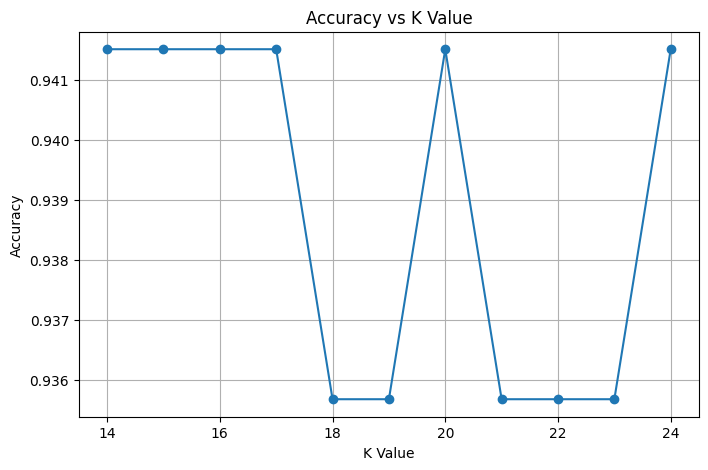

Best K: 14
Best Accuracy: 0.9415204678362573


In [9]:
#train model for heuristic k
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train70, y_train70)

y_pred = knn.predict(X_test70)

accuracy = accuracy_score(y_test70, y_pred)
print("Accuracy:", accuracy)


#experimenting with nearby k values(k±5)
k_values = range(k-5, k+6)

accuracy_list = []

for i in k_values:

    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train70, y_train70)
    pred = model.predict(X_test70)
    acc = accuracy_score(y_test70, pred)
    accuracy_list.append(acc)

result = pd.DataFrame({
    "K Value": list(k_values),
    "Accuracy": accuracy_list
})
print(result)

#plot accuracy vs k
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracy_list, marker='o')
plt.title("Accuracy vs K Value")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


#identifying optimal k
best_k = result.loc[result["Accuracy"].idxmax(),"K Value"]
best_accuracy = result["Accuracy"].max()
print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

**Interpretation**

1. The heuristic method suggested K = 19, and K values from 14 to 24 were tested to find the best performance.
2. Several K values (14, 15, 16, 17, 20, and 24) achieved the highest accuracy of 94.15%.
3. Among them, K = 14 was selected as the optimal K because it is the first K value with the maximum accuracy.

**3.3.  Distance Matrix and Decision Boundary Mapping**
1. Explain any two distance metrics used in KNN: Euclidean Distance and Manhattan Distance. Also mention when each distance metric is suitable.
2. Plot the decision boundary of the KNN classifier for different values of K, such as K = 1, K = 5, K = 10, and K = 20. Analyze how the decision boundary changes as K increase


**Part A: Distance Metrics**

Euclidean Distance
1. Measures the straight-line distance between two data points.
2. Best suited for continuous numerical data.
3. It is the default distance metric used in KNN.


Manhattan Distance
1. Measures the sum of the absolute differences between coordinates.
2. Suitable for grid-like paths and can be less affected by outliers than Euclidean distance.

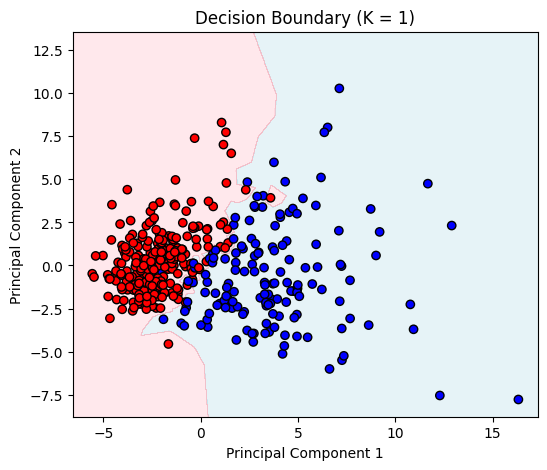

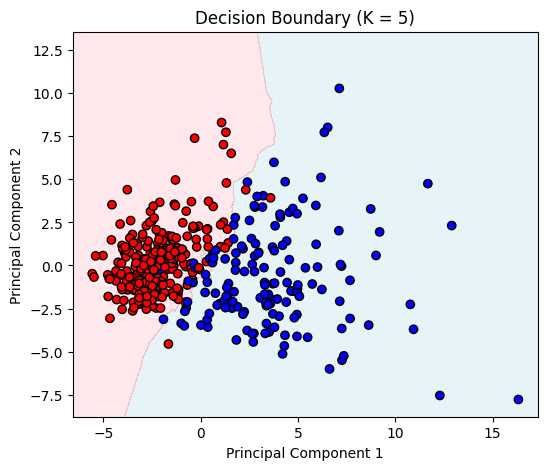

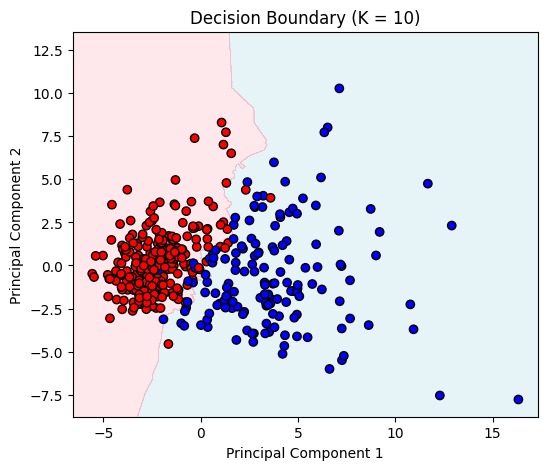

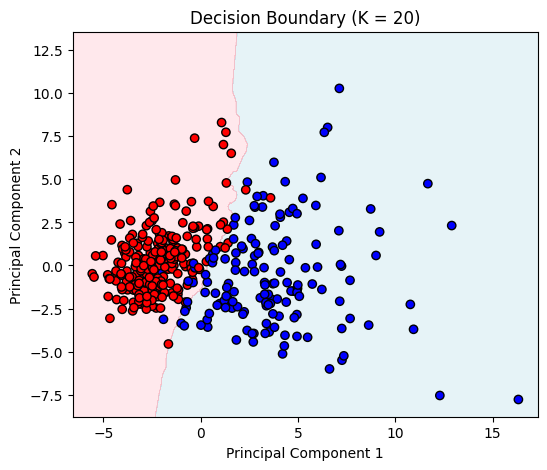

In [10]:
#Part B

from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap


#reducing data to 2 features
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.30, random_state=42)


def plot_boundary(k):

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train, y_train)

    x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
    y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,5))

    plt.contourf(xx, yy, Z, alpha=0.3,
                 cmap=ListedColormap(('lightblue','lightpink')))

    plt.scatter(X_train[:,0], X_train[:,1],
                c=y_train,
                edgecolor='k',
                cmap=ListedColormap(('blue','red')))

    plt.title(f"Decision Boundary (K = {k})")

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")

    plt.show()


#plotting for different k values
plot_boundary(1)
plot_boundary(5)
plot_boundary(10)
plot_boundary(20)

**Interpretation**

1. K = 1: The decision boundary is more irregular and sensitive to individual data points.
2. K = 5: The boundary becomes smoother, giving better generalization.
3. K = 10: The boundary is more stable with fewer small variations.
4. K = 20: The boundary is the smoothest, but it may become too simple and miss some patterns (underfitting).

As K increases, the decision boundary becomes smoother, reducing overfitting but potentially causing underfitting.

**Task 4: Cross Validation**
1. Apply K-Fold Cross Validation (k = 5 or 10).
2. Compute mean accuracy for different K values.
3. Compare cross-validation results with train-test split results.
4. Select best K based on both heuristic + validation results.


    K Value  Mean CV Accuracy
0        14          0.968390
1        15          0.961357
2        16          0.966620
3        17          0.959587
4        18          0.959587
5        19          0.954324
6        20          0.954339
7        21          0.952569
8        22          0.954339
9        23          0.954339
10       24          0.956094


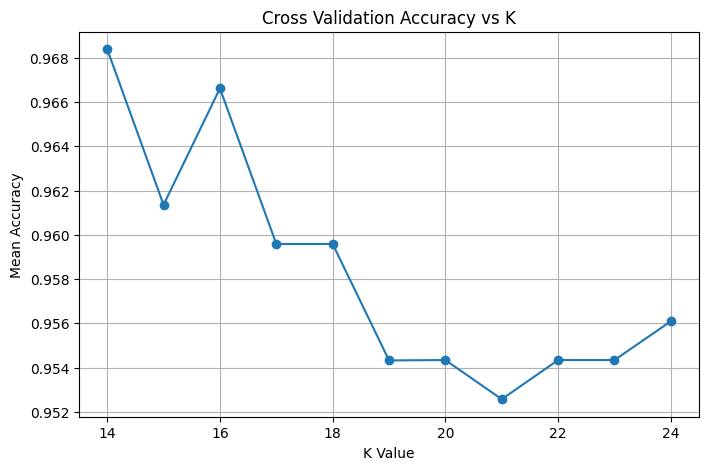

Best K (Cross Validation): 14
Mean Accuracy: 0.968390001552554
             Method  Best K  Accuracy
0  Train-Test Split      14   0.94152
1  Cross Validation      14   0.96839


In [11]:
from sklearn.model_selection import cross_val_score

#5-fold cross validation
k_values = range(14, 25)
cv_accuracy = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=5, scoring='accuracy')
    cv_accuracy.append(scores.mean())


cv_result = pd.DataFrame({
    "K Value": list(k_values),
    "Mean CV Accuracy": cv_accuracy
})

print(cv_result)


plt.figure(figsize=(8,5))
plt.plot(k_values, cv_accuracy, marker='o')
plt.title("Cross Validation Accuracy vs K")
plt.xlabel("K Value")
plt.ylabel("Mean Accuracy")
plt.grid(True)
plt.show()


#best k using cross-validation
best_cv_k = cv_result.loc[cv_result["Mean CV Accuracy"].idxmax(), "K Value"]

best_cv_accuracy = cv_result["Mean CV Accuracy"].max()

print("Best K (Cross Validation):", best_cv_k)
print("Mean Accuracy:", best_cv_accuracy)


#comparing train-test split and cross-validation
comparison = pd.DataFrame({
    "Method": ["Train-Test Split", "Cross Validation"],
    "Best K": [best_k, best_cv_k],
    "Accuracy": [best_accuracy, best_cv_accuracy]
})

print(comparison)

**Interpretation**

1. K = 14 achieved the highest mean cross-validation accuracy (96.84%) and was selected as the best K.
2. Cross Validation (96.84%) gave a higher accuracy than the Train-Test Split (94.15%), indicating a more reliable evaluation of the KNN model.

**Task 5: Classification Evaluation**
Evaluate final model using:
1. Accuracy
2. Precision
3. Recall
4. F1 Score
5. Confusion Matrix
6. ROC Curve and AUC Score


Accuracy : 0.9415204678362573
Precision: 0.9152542372881356
Recall   : 1.0
F1 Score : 0.9557522123893806


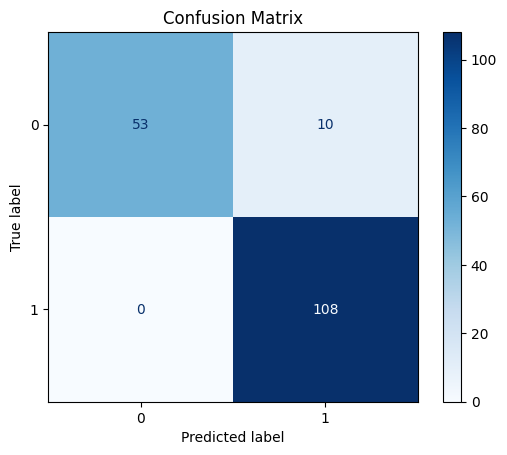

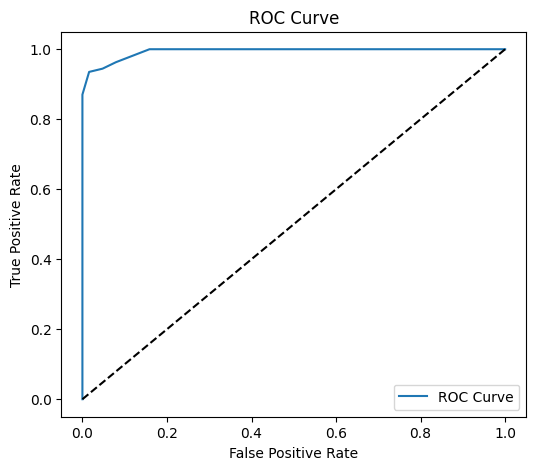

AUC Score: 0.9936067019400352
      Metric     Value
0   Accuracy  0.941520
1  Precision  0.915254
2     Recall  1.000000
3   F1 Score  0.955752
4  AUC Score  0.993607


In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)


knn_final = KNeighborsClassifier(n_neighbors=14)
knn_final.fit(X_train70, y_train70)

y_pred = knn_final.predict(X_test70)


#calculating evaluation metrics
accuracy = accuracy_score(y_test70, y_pred)
precision = precision_score(y_test70, y_pred)
recall = recall_score(y_test70, y_pred)
f1 = f1_score(y_test70, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


#confusion matrix
cm = confusion_matrix(y_test70, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


#ROC curve
y_prob = knn_final.predict_proba(X_test70)[:,1]

fpr, tpr, thresholds = roc_curve(y_test70, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


#AUC score
auc = roc_auc_score(y_test70, y_prob)
print("AUC Score:", auc)


results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "AUC Score"],
    "Value": [accuracy, precision, recall, f1, auc]
})

print(results)

**Interpretation of Evaluation Metrics**
1. The model achieved 94.15% accuracy, indicating good overall classification performance.
2. The precision (91.53%) shows that most positive predictions made by the model were correct.
3. The recall (100%) indicates that the model correctly identified all actual positive cases.
4. The F1-score (95.58%) shows a good balance between precision and recall.
5. The AUC score (0.9936) is very close to 1, indicating excellent classification performance.


**Confusion Matrix Interpretation**
1. The model correctly classified 53 negative and 108 positive samples.
2. It misclassified 10 negative samples as positive and did not miss any positive samples, showing excellent detection of positive cases.


**ROC Curve Interpretation**
1. The ROC curve is close to the top-left corner, indicating excellent class separation.
2. The high AUC score (0.9936) confirms that the KNN model distinguishes between the two classes very effectively.

**Task 6: Comparative Study with Regression (Lab 3 Integration)**
Reference: Recall Lab 3 (Linear Regression) where you evaluated:MAE,MSE, RMSE, R² Score

**Tasks:**
1. Compare regression evaluation metrics with classification metrics.



| Regression Metric | Classification Metric | Explanation                                                                                                                         |
| ----------------- | --------------------- | ----------------------------------------------------------------------------------------------------------------------------------- |
| **MAE**           | **Accuracy**          | MAE measures the average prediction error, while Accuracy measures the percentage of correct predictions.                           |
| **MSE**           | **Precision**         | MSE gives more weight to large errors, while Precision measures how many predicted positive cases are actually positive.            |
| **RMSE**          | **Recall**            | RMSE measures prediction error in the original unit, while Recall measures how many actual positive cases are correctly identified. |
| **R² Score**      | **F1 Score**          | R² shows how well the regression model fits the data, while F1 Score balances Precision and Recall.                                 |


2. Explain differences between:

    a. Error-based evaluation (Regression)

    b. Decision-based evaluation (Classification)

| Error-based Evaluation (Regression)                  | Decision-based Evaluation (Classification)              |
| ---------------------------------------------------- | ------------------------------------------------------- |
| Predicts continuous numerical values.                | Predicts class labels such as 0/1 or Yes/No.            |
| Measures how far predictions are from actual values. | Measures how correctly the model classifies data.       |
| Uses MAE, MSE, RMSE and R² Score.                    | Uses Accuracy, Precision, Recall, F1 Score and ROC-AUC. |
| Lower error values indicate better performance.      | Higher metric values indicate better performance.       |


3. Compare:

    a. R² Score vs Accuracy

    b. RMSE vs F1 Score

    c. MAE vs Confusion Matrix


| Metric Comparison           | Explanation                                                                                                                    |
| --------------------------- | ------------------------------------------------------------------------------------------------------------------------------ |
| **R² Score vs Accuracy**    | R² measures how well numerical values are predicted, whereas Accuracy measures the percentage of correctly classified samples. |
| **RMSE vs F1 Score**        | RMSE measures prediction error, whereas F1 Score balances Precision and Recall for classification.                             |
| **MAE vs Confusion Matrix** | MAE gives the average prediction error, whereas the Confusion Matrix shows correct and incorrect classifications.              |



4. Discuss differences in evaluation logic for:

    a. Continuous prediction tasks
    b. Classification tasks

| Continuous Prediction                                           | Classification                                                 |
| --------------------------------------------------------------- | -------------------------------------------------------------- |
| Predicts numerical values such as house prices or temperatures. | Predicts categories such as Benign/Malignant or Spam/Not Spam. |
| Output is a continuous number.                                  | Output is a class label.                                       |
| Uses regression evaluation metrics.                             | Uses classification evaluation metrics.                        |
